In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

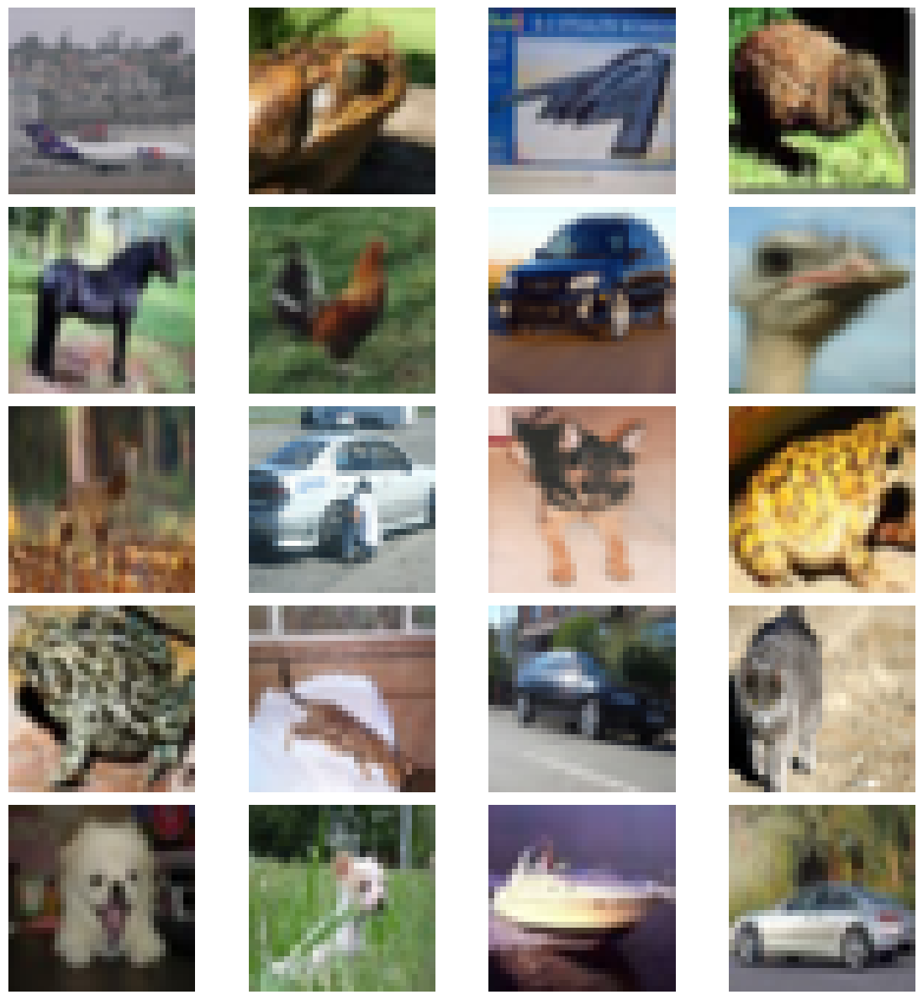

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset from Hugging Face
dataset = load_dataset("uoft-cs/cifar10")


def show_images(dataset, split="train", num_samples=20, cols=4):
    """
    Display sample images from the Hugging Face CIFAR-10 dataset.
    """
    plt.figure(figsize=(12, 12))

    for i in range(num_samples):
        image = dataset[split][i]["img"]

        plt.subplot((num_samples + cols - 1) // cols, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Visualize some training images
show_images(dataset)

In [3]:
import torch
import torch.nn.functional as F


class NoiseScheduler:
    """
    Handles the forward diffusion process by creating the noise schedule
    and adding noise to images.
    """

    def __init__(
        self,
        noise_steps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cpu"
    ):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.device = device

        # Create beta schedule
        self.betas = self.linear_beta_schedule()

        # Compute alpha values
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

        self.alpha_hat_prev = F.pad(
            self.alpha_hat[:-1],
            (1, 0),
            value=1.0
        )

        # Frequently used terms
        self.sqrt_alpha_hat = torch.sqrt(self.alpha_hat)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1.0 - self.alpha_hat)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / self.alphas)

        self.posterior_variance = (
            self.betas
            * (1.0 - self.alpha_hat_prev)
            / (1.0 - self.alpha_hat)
        )

    def linear_beta_schedule(self):
        """
        Linear noise schedule.
        """
        return torch.linspace(
            self.beta_start,
            self.beta_end,
            self.noise_steps,
            device=self.device
        )

    def get_index_from_list(self, values, t, x_shape):
        """
        Returns values corresponding to timestep t for every image
        in the batch.
        """
        batch_size = t.shape[0]

        out = values.gather(0, t)

        return out.reshape(
            batch_size,
            *((1,) * (len(x_shape) - 1))
        )

    def noise_images(self, x, t):
        """
        Forward diffusion:
        q(x_t | x_0)

        Adds Gaussian noise to an image.
        """
        noise = torch.randn_like(x)

        sqrt_alpha_hat = self.get_index_from_list(
            self.sqrt_alpha_hat,
            t,
            x.shape
        )

        sqrt_one_minus_alpha_hat = self.get_index_from_list(
            self.sqrt_one_minus_alpha_hat,
            t,
            x.shape
        )

        noisy_image = (
            sqrt_alpha_hat * x
            + sqrt_one_minus_alpha_hat * noise
        )

        return noisy_image, noise

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class CIFAR10Dataset(Dataset):
    """
    PyTorch wrapper around the Hugging Face CIFAR-10 dataset.
    """

    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["img"]      # PIL Image
        label = sample["label"]    # Not used for unconditional diffusion

        if self.transform:
            image = self.transform(image)

        return image


class DatasetLoader:
    """
    Loads and preprocesses the CIFAR-10 dataset.
    """

    def __init__(self, cfg):
        self.cfg = cfg

        self.transform = transforms.Compose([
            transforms.Resize((cfg.image_size, cfg.image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.5, 0.5, 0.5),
                std=(0.5, 0.5, 0.5)
            )
        ])

    def get_dataloader(self):

        dataset = load_dataset("uoft-cs/cifar10")

        train_dataset = CIFAR10Dataset(
            dataset["train"],
            transform=self.transform
        )

        dataloader = DataLoader(
            train_dataset,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            num_workers=self.cfg.num_workers,
            drop_last=True,
            pin_memory=True
        )

        return dataloader


def show_tensor_image(image):
    """
    Convert tensor in [-1,1] back to a PIL image for visualization.
    """

    reverse_transform = transforms.Compose([
        transforms.Normalize(
            mean=(-1, -1, -1),
            std=(2, 2, 2)
        ),
        transforms.Lambda(lambda t: torch.clamp(t, 0, 1)),
        transforms.ToPILImage()
    ])

    if image.ndim == 4:
        image = image[0]

    plt.imshow(reverse_transform(image.cpu()))
    plt.axis("off")
    plt.show()

class Config:
    image_size = 32
    batch_size = 128
    num_workers = 2
    device = "cuda" if torch.cuda.is_available() else "cpu"
    in_channels = 3
    time_dim = 256
    features = [64, 128, 256]
    learning_rate = 3e-4
    epochs = 100


cfg = Config()
# Create DataLoader
dataset_loader = DatasetLoader(cfg)
train_loader = dataset_loader.get_dataloader()

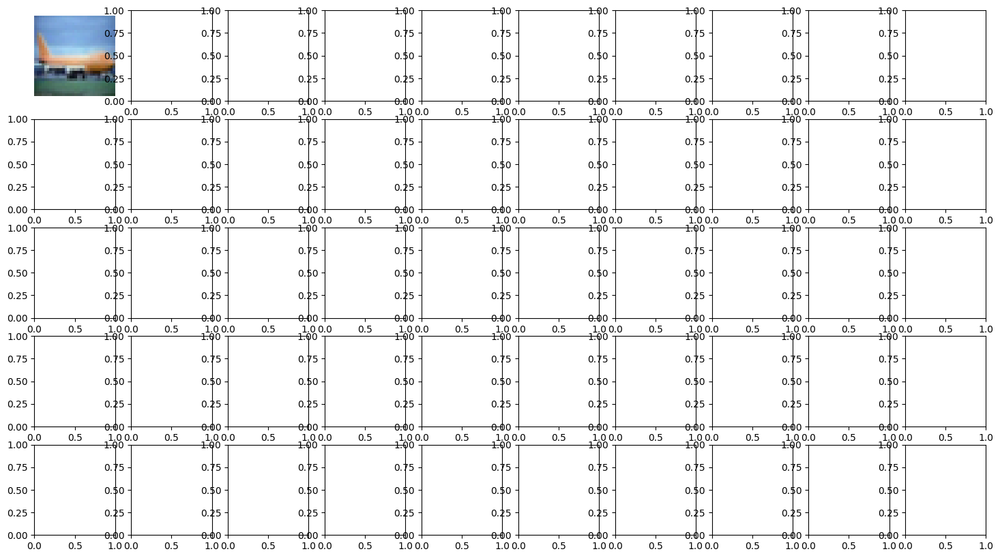

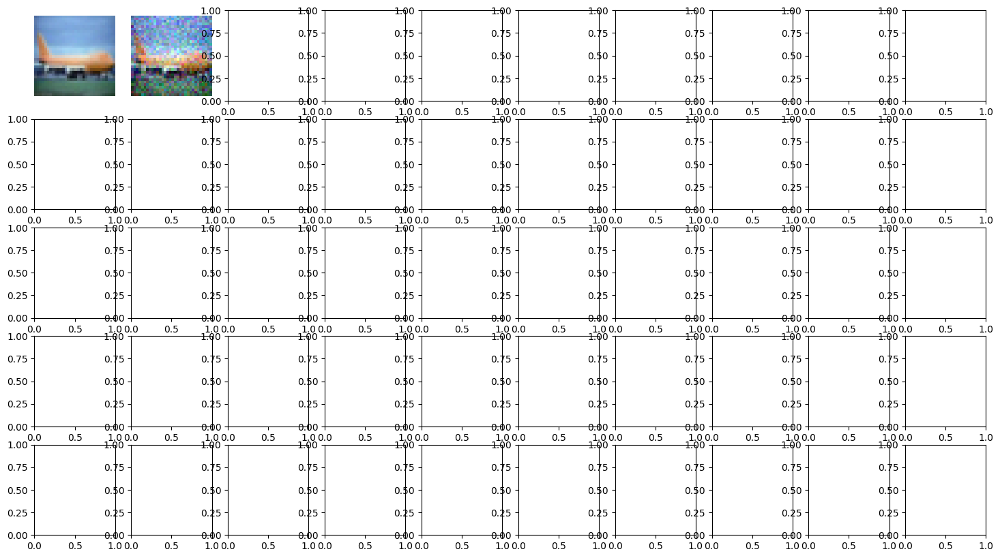

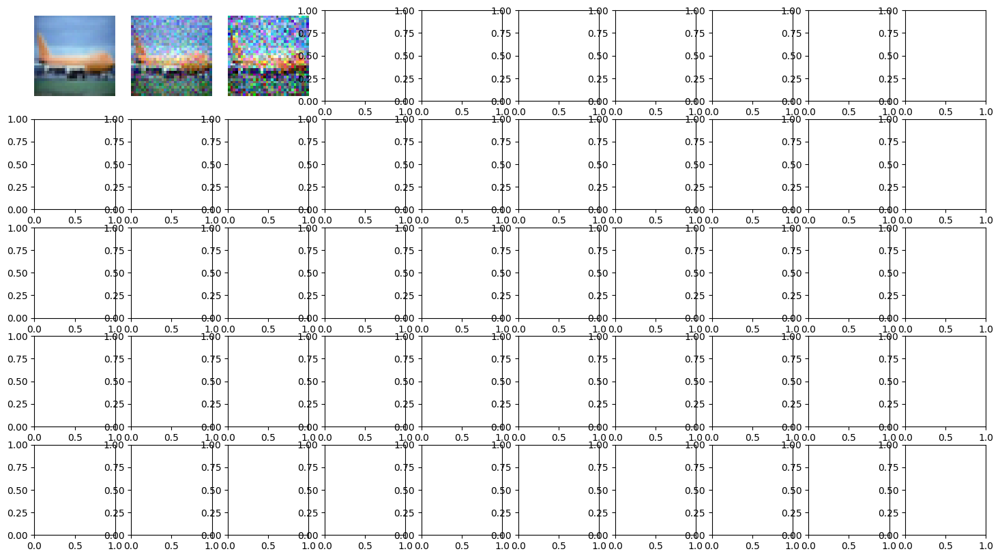

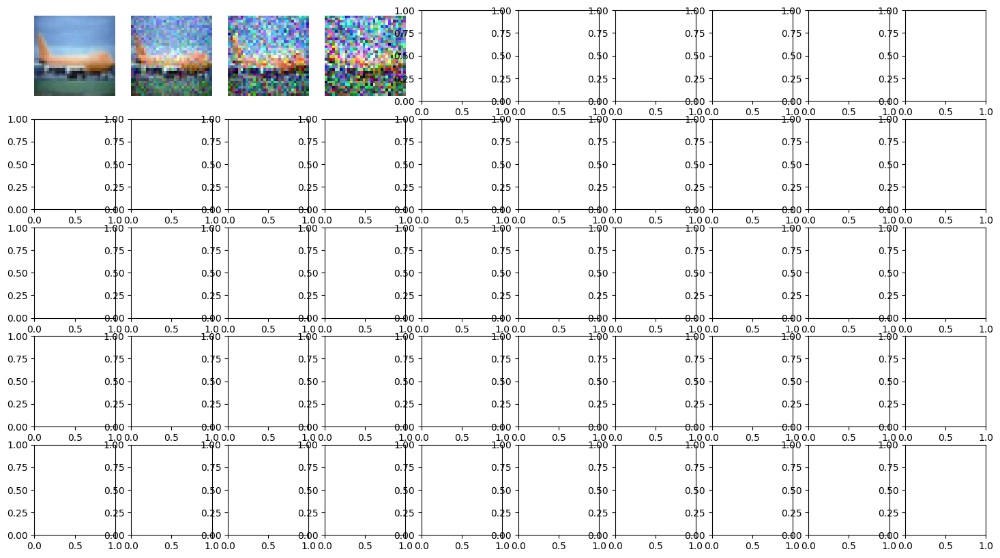

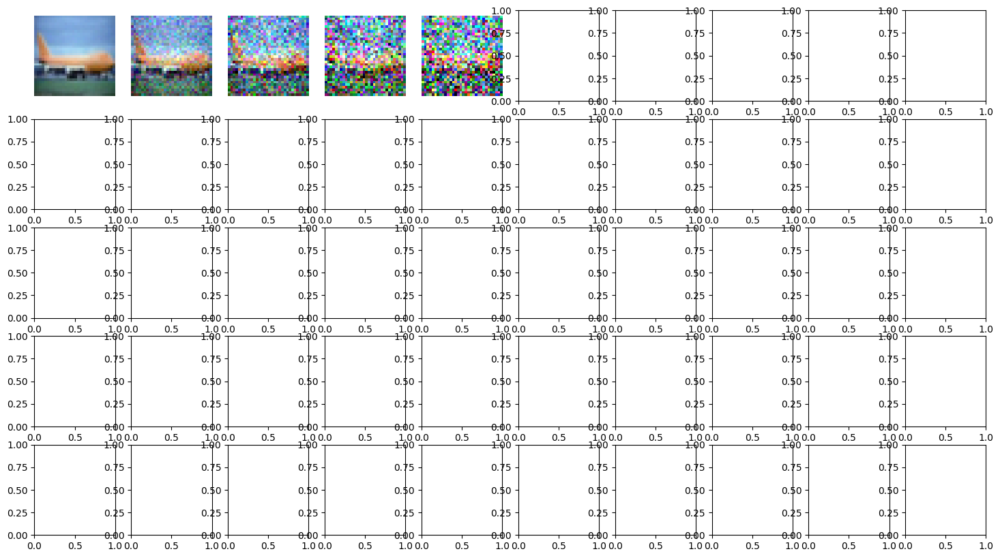

...

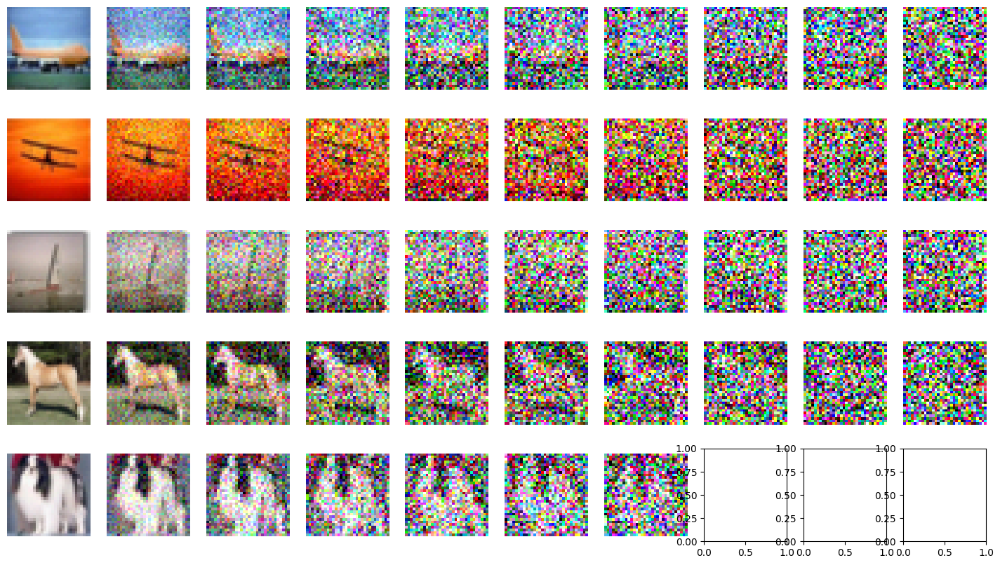

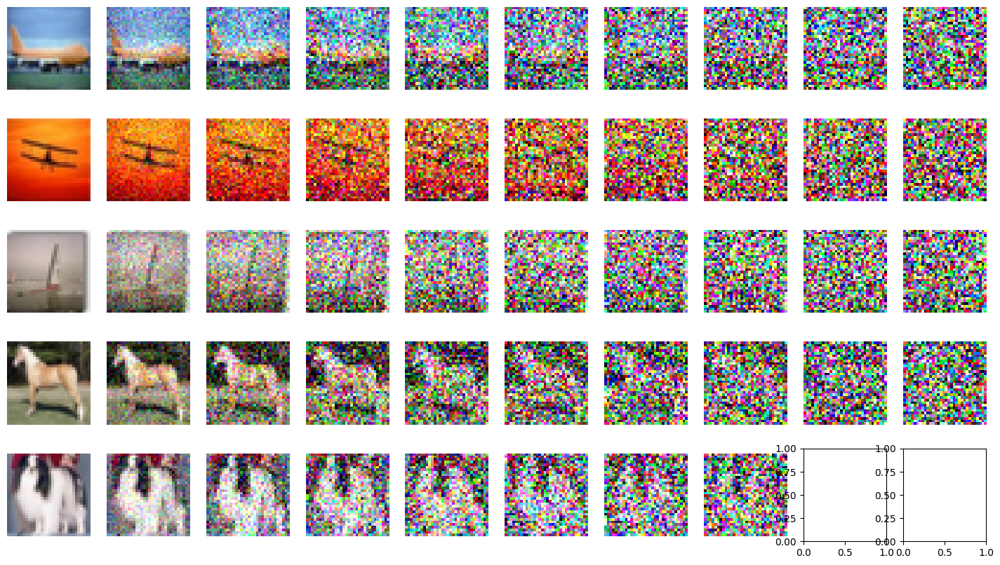

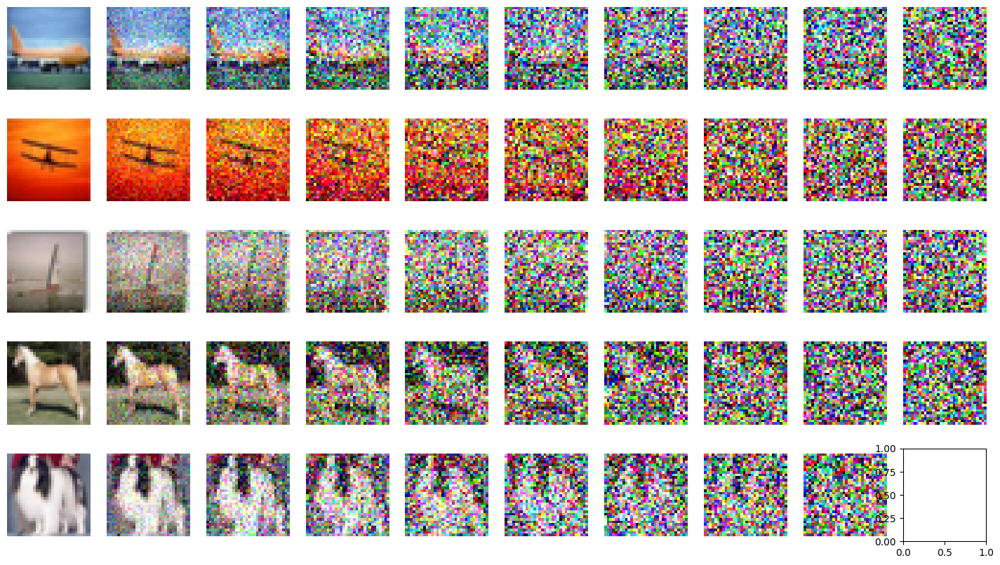

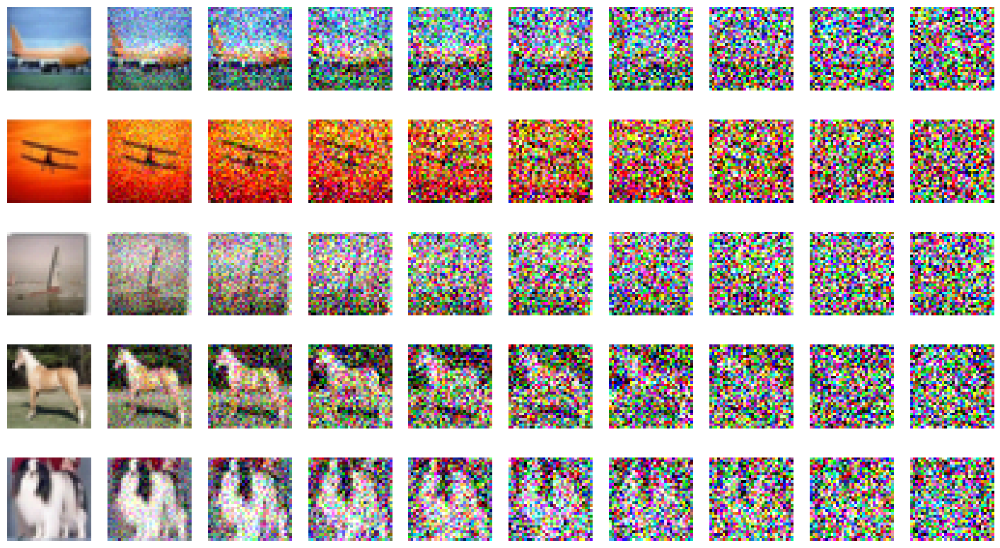

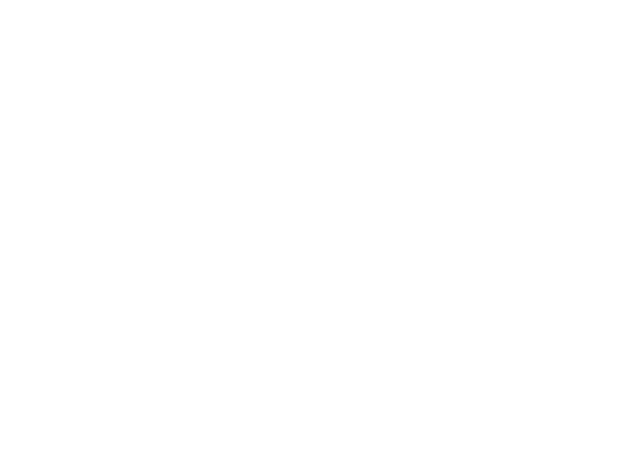

In [6]:
# Create Noise Scheduler
noise_scheduler = NoiseScheduler(
    noise_steps=300,
    device=cfg.device
)

# Get one batch of images
images = next(iter(train_loader))

# Number of images and timesteps to visualize
num_images = 5
num_timesteps = 10

fig, axes = plt.subplots(
    num_images,
    num_timesteps,
    figsize=(18, 10)
)

stepsize = noise_scheduler.noise_steps // (num_timesteps - 1)

for row in range(num_images):

    image = images[row].unsqueeze(0).to(cfg.device)

    for col, timestep in enumerate(range(0, noise_scheduler.noise_steps, stepsize)):

        if col >= num_timesteps:
            break

        t = torch.tensor([timestep], device=cfg.device)

        noisy_image, _ = noise_scheduler.noise_images(image, t)

        plt.sca(axes[row, col])
        show_tensor_image(noisy_image)
        plt.axis("off")

        if row == 0:
            plt.title(f"t={timestep}")

plt.tight_layout()
plt.show()

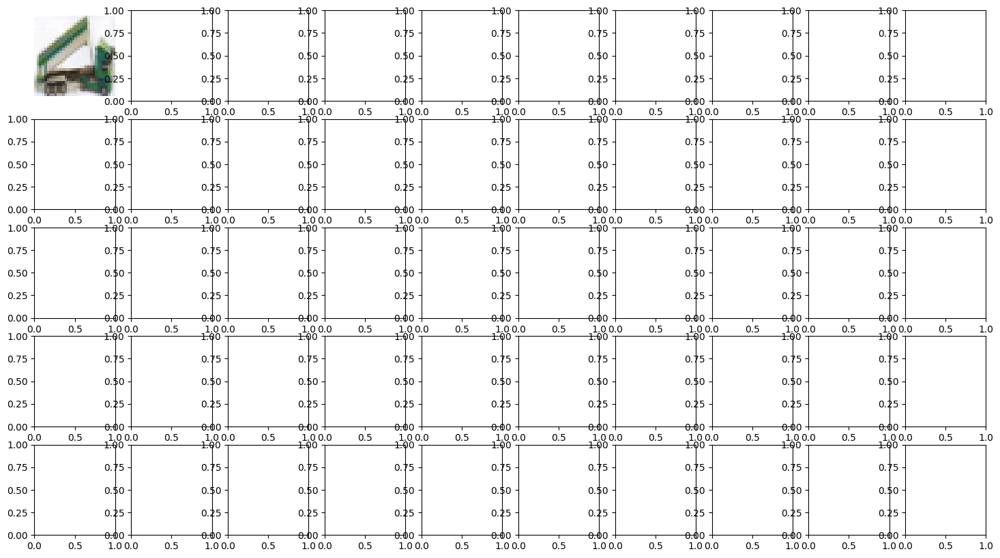

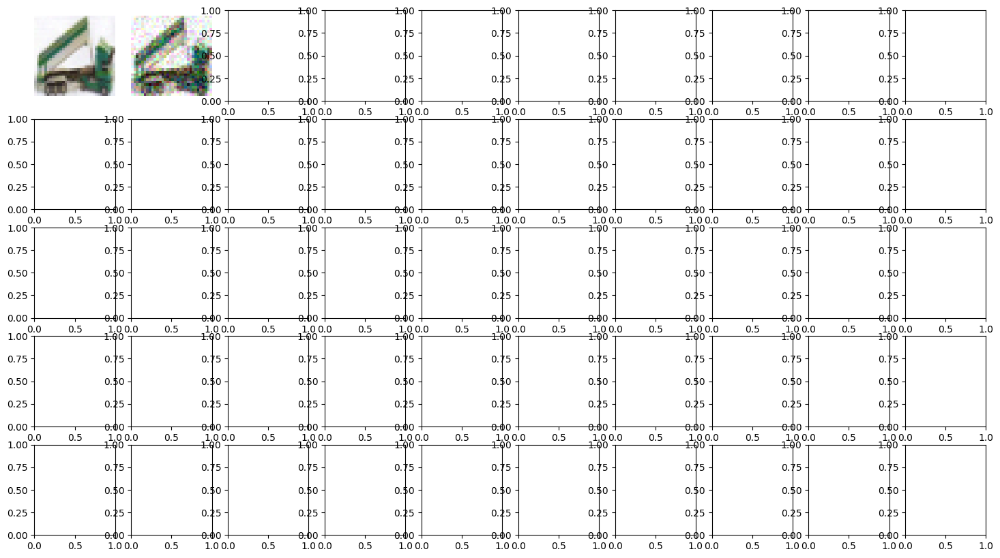

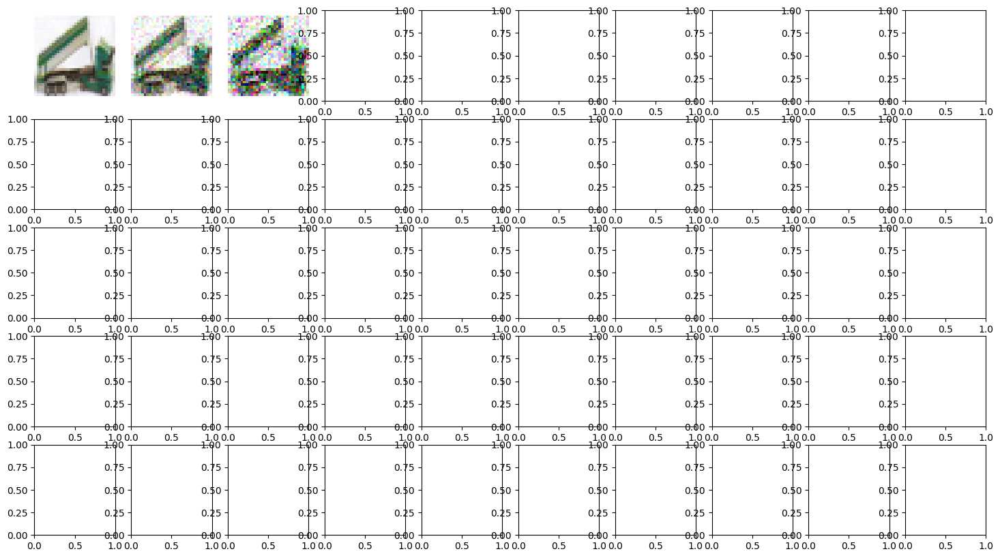

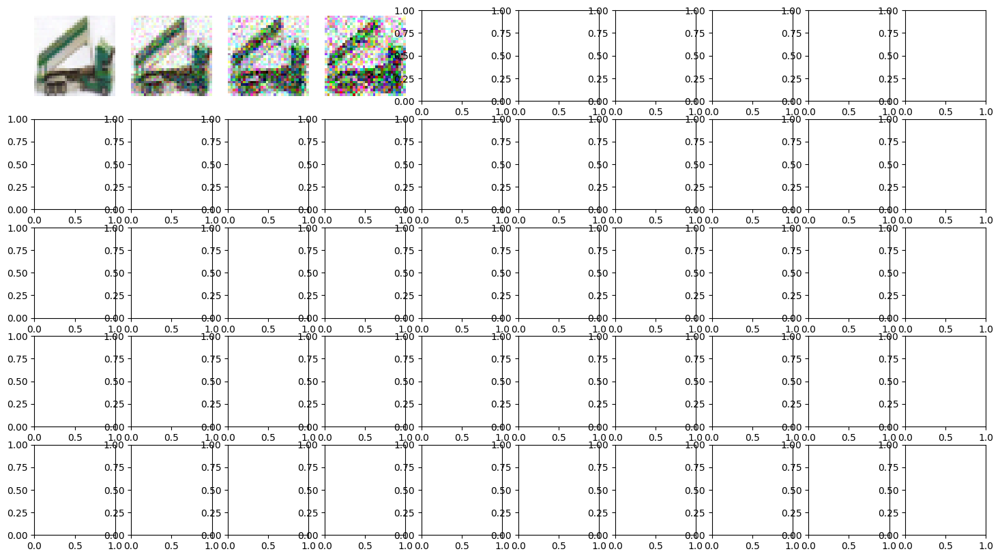

KeyboardInterrupt: 

In [7]:
# Create Noise Scheduler
noise_scheduler = NoiseScheduler(
    noise_steps=300,
    device=cfg.device
)

# Get one batch of images
images = next(iter(train_loader))

# Number of images and timesteps to visualize
num_images = 5
num_timesteps = 10

fig, axes = plt.subplots(
    num_images,
    num_timesteps,
    figsize=(18, 10)
)

stepsize = noise_scheduler.noise_steps // (num_timesteps - 1)

for row in range(num_images):

    image = images[row].unsqueeze(0).to(cfg.device)

    for col, timestep in enumerate(range(0, noise_scheduler.noise_steps, stepsize)):

        if col >= num_timesteps:
            break

        t = torch.tensor([timestep], device=cfg.device)

        noisy_image, _ = noise_scheduler.noise_images(image, t)

        plt.sca(axes[row, col])
        show_tensor_image(noisy_image)
        plt.axis("off")

        if row == 0:
            plt.title(f"t={timestep}")

plt.tight_layout()
plt.show()

In [8]:
import math
import torch
import torch.nn as nn


class SinusoidalPositionEmbedding(nn.Module):
    """
    Converts a timestep t into a high-dimensional embedding.

    Input:
        t : (B,)

    Output:
        embedding : (B, time_dim)
    """

    def __init__(self, time_dim):
        super().__init__()
        self.time_dim = time_dim

    def forward(self, t):

        device = t.device

        half_dim = self.time_dim // 2

        embeddings = math.log(10000) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )

        embeddings = t[:, None] * embeddings[None, :]

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=-1
        )

        return embeddings

In [9]:
class DoubleConv(nn.Module):
    """
    Two convolution layers with GroupNorm and GELU.
    Time embedding is added after the first convolution.
    """

    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
        )

        self.time_embedding = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )

    def forward(self, x, t):

        # First convolution
        x = self.conv1(x)

        # Project time embedding
        emb = self.time_embedding(t)

        # Shape:
        # (B, C) -> (B, C, 1, 1)
        emb = emb[:, :, None, None]

        # Add time information
        x = x + emb

        # Second convolution
        x = self.conv2(x)

        return x

In [10]:
class DownBlock(nn.Module):
    """
    Encoder block:
    DoubleConv -> Downsample

    Returns:
        x    : Downsampled feature map
        skip : Feature map before downsampling (for skip connection)
    """

    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels,
            time_dim
        )

        self.down = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t):

        x = self.conv(x, t)

        skip = x

        x = self.down(x)

        return x, skip

In [11]:
class UpBlock(nn.Module):
    """
    Decoder block:
    Upsample -> Concatenate Skip Connection -> DoubleConv
    """

    def __init__(self, in_channels,skip_channels, out_channels, time_dim):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels,
            time_dim
        )

    def forward(self, x, skip, t):

        # Upsample
        x = self.up(x)

        # Concatenate encoder features
        x = torch.cat([x, skip], dim=1)

        # Convolution
        x = self.conv(x, t)

        return x

In [12]:
class UNet(nn.Module):
    """
    Modular UNet for DDPM.
    """

    def __init__(self, cfg):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalPositionEmbedding(cfg.time_dim),
            nn.Linear(cfg.time_dim, cfg.time_dim),
            nn.GELU()
        )

        # Initial projection
        self.input_conv = nn.Conv2d(
            cfg.in_channels,
            cfg.features[0],
            kernel_size=3,
            padding=1
        )

        # Encoder
        self.down1 = DownBlock(
            cfg.features[0],
            cfg.features[1],
            cfg.time_dim
        )

        self.down2 = DownBlock(
            cfg.features[1],
            cfg.features[2],
            cfg.time_dim
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            cfg.features[2],
            cfg.features[2],
            cfg.time_dim
        )

        # Decoder
        self.up1 = UpBlock(
          in_channels=cfg.features[2],
          skip_channels=cfg.features[2],
          out_channels=cfg.features[1],
          time_dim=cfg.time_dim
)

        self.up2 = UpBlock(
            in_channels=cfg.features[1],
            skip_channels=cfg.features[1],
            out_channels=cfg.features[0],
            time_dim=cfg.time_dim
        )

        # Final output
        self.output_conv = nn.Conv2d(
            cfg.features[0],
            cfg.in_channels,
            kernel_size=1
        )

    def forward(self, x, t):

        # Time embedding
        t = self.time_embedding(t)

        # Initial convolution
        x = self.input_conv(x)

        # Encoder
        x, skip1 = self.down1(x, t)
        x, skip2 = self.down2(x, t)

        # Bottleneck
        x = self.bottleneck(x, t)

        # Decoder
        x = self.up1(x, skip2, t)
        x = self.up2(x, skip1, t)

        # Predict noise
        return self.output_conv(x)

In [13]:
# Create model
model = UNet(cfg).to(cfg.device)

# Print parameter count
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {num_params:,}")

# Create a dummy batch
dummy_images = torch.randn(
    cfg.batch_size,
    cfg.in_channels,
    cfg.image_size,
    cfg.image_size
).to(cfg.device)

# Random timesteps
dummy_timesteps = torch.randint(
    low=0,
    high=300,
    size=(cfg.batch_size,),
    device=cfg.device
)

# Forward pass
with torch.no_grad():
    output = model(dummy_images, dummy_timesteps)

print(f"Input Shape : {dummy_images.shape}")
print(f"Output Shape: {output.shape}")

Number of parameters: 5,276,099
Input Shape : torch.Size([128, 3, 32, 32])
Output Shape: torch.Size([128, 3, 32, 32])


In [14]:
def get_loss(model, noise_scheduler, images, timesteps):
    """
    Computes the DDPM training loss.
    """

    noisy_images, noise = noise_scheduler.noise_images(
        images,
        timesteps
    )

    predicted_noise = model(
        noisy_images,
        timesteps
    )

    loss = F.l1_loss(
        predicted_noise,
        noise
    )

    return loss

In [15]:
class Diffusion:
    """
    DDPM pipeline.

    Responsible for:
    - Sampling random timesteps
    - Forward diffusion during training
    - Reverse diffusion during inference
    """

    def __init__(self, model, noise_scheduler, cfg):

        self.model = model
        self.scheduler = noise_scheduler
        self.cfg = cfg

    def sample_timesteps(self, batch_size):
        """
        Sample a random timestep for every image in the batch.
        """

        return torch.randint(
            low=0,
            high=self.scheduler.noise_steps,
            size=(batch_size,),
            device=self.cfg.device
        )

    def forward_step(self, images):
        """
        One forward diffusion step used during training.

        Returns:
            noisy_images
            predicted_noise
            true_noise
            timesteps
        """

        timesteps = self.sample_timesteps(images.shape[0])

        noisy_images, noise = self.scheduler.noise_images(
            images,
            timesteps
        )

        predicted_noise = self.model(
            noisy_images,
            timesteps
        )

        return (
            noisy_images,
            predicted_noise,
            noise,
            timesteps
        )

    @torch.no_grad()
    def sample_step(self, x, t):
        """
        Perform one reverse diffusion step.
        """

        betas = self.scheduler.get_index_from_list(
            self.scheduler.betas,
            t,
            x.shape
        )

        sqrt_one_minus_alpha_hat = self.scheduler.get_index_from_list(
            self.scheduler.sqrt_one_minus_alpha_hat,
            t,
            x.shape
        )

        sqrt_recip_alpha = self.scheduler.get_index_from_list(
            self.scheduler.sqrt_recip_alpha,
            t,
            x.shape
        )

        predicted_noise = self.model(x, t)

        model_mean = sqrt_recip_alpha * (
            x -
            betas * predicted_noise /
            sqrt_one_minus_alpha_hat
        )

        posterior_variance = self.scheduler.get_index_from_list(
            self.scheduler.posterior_variance,
            t,
            x.shape
        )

        if t[0] == 0:
            return model_mean

        noise = torch.randn_like(x)

        return model_mean + torch.sqrt(
            posterior_variance
        ) * noise

    @torch.no_grad()
    def sample(self, num_images=1):
        """
        Generate new images from pure Gaussian noise.
        """

        self.model.eval()

        x = torch.randn(
            (
                num_images,
                self.cfg.in_channels,
                self.cfg.image_size,
                self.cfg.image_size,
            ),
            device=self.cfg.device,
        )

        for timestep in reversed(range(self.scheduler.noise_steps)):

            t = torch.full(
                (num_images,),
                timestep,
                device=self.cfg.device,
                dtype=torch.long,
            )

            x = self.sample_step(x, t)

            x = torch.clamp(
                x,
                -1,
                1
            )

        self.model.train()

        return x

    @torch.no_grad()
    def deploy(self, num_images=5):
        """
        Generate and visualize images.
        """

        generated_images = self.sample(num_images)

        fig, axes = plt.subplots(
            1,
            num_images,
            figsize=(3 * num_images, 3)
        )

        if num_images == 1:
            axes = [axes]

        for i in range(num_images):

            plt.sca(axes[i])

            plt.imshow(
                show_tensor_image(
                    generated_images[i]
                )
            )

            plt.axis("off")

        plt.tight_layout()
        plt.show()

In [16]:
diffusion = Diffusion(
    model=model,
    noise_scheduler=noise_scheduler,
    cfg=cfg
)

In [20]:
import os

In [22]:
import torch.optim as optim
from tqdm.auto import tqdm


class Trainer:
    """
    Handles model training.
    """

    def __init__(
        self,
        diffusion,
        train_loader,
        cfg
    ):
        self.diffusion = diffusion
        self.train_loader = train_loader
        self.cfg = cfg

        self.optimizer = optim.Adam(
            self.diffusion.model.parameters(),
            lr=cfg.learning_rate
        )

        self.loss_fn = nn.L1Loss()
        import os

        self.checkpoint_dir = "checkpoints"
        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def train_epoch(self):

        self.diffusion.model.train()

        running_loss = 0

        progress_bar = tqdm(self.train_loader)

        for images in progress_bar:

            images = images.to(self.cfg.device)

            _, predicted_noise, true_noise, _ = (
                self.diffusion.forward_step(images)
            )

            loss = self.loss_fn(
                predicted_noise,
                true_noise
            )

            self.optimizer.zero_grad()

            loss.backward()

            self.optimizer.step()

            running_loss += loss.item()

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

        return running_loss / len(self.train_loader)

    def train(self):

        start_epoch = self.load_checkpoint()

        for epoch in range(start_epoch,self.cfg.epochs):

            avg_loss = self.train_epoch()

            print(
                f"Epoch {epoch+1}/{self.cfg.epochs} "
                f"| Loss: {avg_loss:.4f}"
            )
            self.save_checkpoint(epoch)
    def save_checkpoint(self, epoch):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.diffusion.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict()
        }

        torch.save(
            checkpoint,
            f"{self.checkpoint_dir}/latest_checkpoint.pth"
        )


    def load_checkpoint(self):
        checkpoint_path = f"{self.checkpoint_dir}/latest_checkpoint.pth"

        if not os.path.exists(checkpoint_path):
            print("No checkpoint found. Training from scratch.")
            return 0

        checkpoint = torch.load(
            checkpoint_path,
            map_location=self.cfg.device
        )

        self.diffusion.model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        self.optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        print(f"Resuming from epoch {start_epoch}")

        return start_epoch

In [23]:
trainer = Trainer(
    diffusion=diffusion,
    train_loader=train_loader,
    cfg=cfg
)

In [ ]:
trainer.train()

No checkpoint found. Training from scratch.


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 1/100 | Loss: 0.1615


  0%|          | 0/390 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be8080f4360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be8080f4360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 2/100 | Loss: 0.1603


  0%|          | 0/390 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be8080f4360>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be8080f4360>

Exception ignored in: AssertionErrorTraceback (most recent call last):
:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
can only test a child process<function _MultiProcessingDataLoaderIter.__del__ at 0x7be8080f4360>
    
Traceback (most recent 

Epoch 3/100 | Loss: 0.1595


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 4/100 | Loss: 0.1597


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 5/100 | Loss: 0.1589


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 6/100 | Loss: 0.1594


  0%|          | 0/390 [00:00<?, ?it/s]

In [29]:
import torch

print(torch.cuda.is_available())
print(cfg.device)

False
cpu
